In [1]:
import pandas as pd
from sqlalchemy import create_engine
import mplfinance as mpf
import ta
import matplotlib.pyplot as plt

# Database credentials
db_config = {
    'host': 'localhost',
    'user': 'root',
    'password': 'Tamir4578',
    'database': 'portalblog_dev'
}

table_name = 'analyzed_data'
timestamp_col = 'time'
open_col = 'open'
high_col = 'high'
low_col = 'low'
close_col = 'close'

# Create database connection string
db_connection_str = 'mysql+pymysql://{user}:{password}@{host}/{database}'.format(**db_config)
db_connection = create_engine(db_connection_str)
def fetch_data_from_db(window_size=500, start_date=None, end_date=None):
    query = f'SELECT * FROM (SELECT * FROM {table_name} ORDER BY {timestamp_col} DESC LIMIT {window_size}) AS recent_data'
    if start_date and end_date:
        query = f'SELECT * FROM (SELECT * FROM {table_name} WHERE {timestamp_col} BETWEEN "{start_date}" AND "{end_date}" ORDER BY {timestamp_col} DESC LIMIT {window_size}) AS recent_data'
    query += f' ORDER BY {timestamp_col} ASC'
    df = pd.read_sql(query, db_connection)
    # Convert the 'time' column to datetime
    df['time'] = pd.to_datetime(df['time'])

    # Set the 'time' column as the index
    df.set_index('time', inplace=True)
    return df
# df = pd.read_sql(query, db_connection)
df = fetch_data_from_db()
df.head()

,id,open,high,low,close,volume,resistance,support,macd,macd_signal,...,rsi_trade,stochastic_trade,channel_trade,bb_upper,bb_middle,bb_lower,bb_trend,bb_signal,near_bb_support,near_bb_resistance
time,,,,,,,,,,,,,,,,,,,,,
2025-01-21 14:00:00,492,3309.69,3335.44,3279.09,3289.41,46772.6,None,None,None,None,...,wait,wait,wait,3345.15,3278.17,3211.20,sideways,wait,NaN,3335.44
2025-01-21 15:00:00,493,3289.42,3302.09,3265.11,3295.10,27063.4,None,None,None,None,...,wait,wait,wait,3335.94,3275.75,3215.56,sideways,wait,NaN,NaN
2025-01-21 16:00:00,494,3295.10,3349.17,3290.50,3313.85,34589.3,None,None,None,None,...,wait,wait,wait,3334.69,3275.43,3216.18,sideways,wait,NaN,NaN
2025-01-21 17:00:00,495,3313.85,3356.59,3307.81,3351.00,20466.4,None,None,None,None,...,wait,wait,wait,3346.92,3278.74,3210.55,sideways,wait,NaN,3356.59
2025-01-21 18:00:00,496,3351.00,3368.00,3330.74,3345.76,21973.6,None,None,None,None,...,wait,sell,wait,3352.58,3280.10,3207.62,sideways,wait,NaN,NaN


# Testing tactic for combination of BB and OSCI.

osci_bb_buy count: 15
osci_bb_sell count: 26


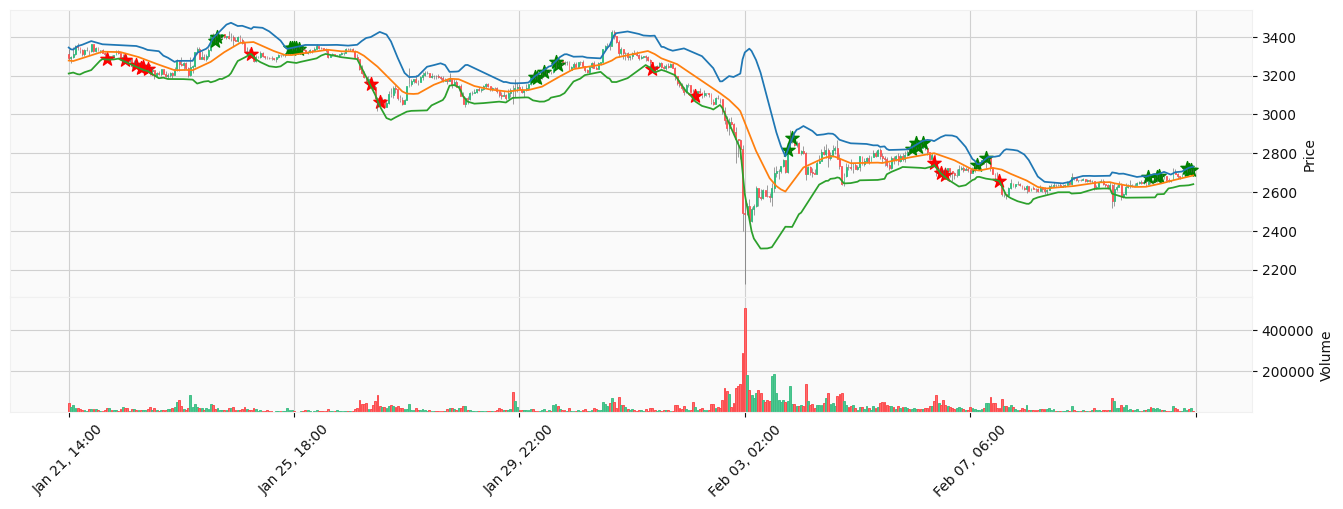

In [33]:
df['osci_bb_buy'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_support']) and row['stochastic_trade'] == 'buy' else None, axis=1)
df['osci_bb_sell'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_resistance']) and row['stochastic_trade'] == 'sell' else None, axis=1)
osci_bb_buy_count = df['osci_bb_buy'].count()
osci_bb_sell_count = df['osci_bb_sell'].count()

print(f"osci_bb_buy count: {osci_bb_buy_count}")
print(f"osci_bb_sell count: {osci_bb_sell_count}")

# Define the Bollinger Bands
bbands = mpf.make_addplot(df[['bb_upper', 'bb_middle', 'bb_lower']])

# Define the buy and sell signals
buy_signals = mpf.make_addplot(df['osci_bb_buy'], type='scatter', markersize=100, marker='*', color='red')
sell_signals = mpf.make_addplot(df['osci_bb_sell'], type='scatter', markersize=100, marker='*', color='green')

# Plot the candlestick chart with Bollinger Bands and buy/sell signals
mpf.plot(df, type='candle', addplot=[bbands, buy_signals, sell_signals], volume=True, style='yahoo', figratio=(3, 1))

# Testing the combination of BB and RSI

osci_bb_buy count: 9
osci_bb_sell count: 10


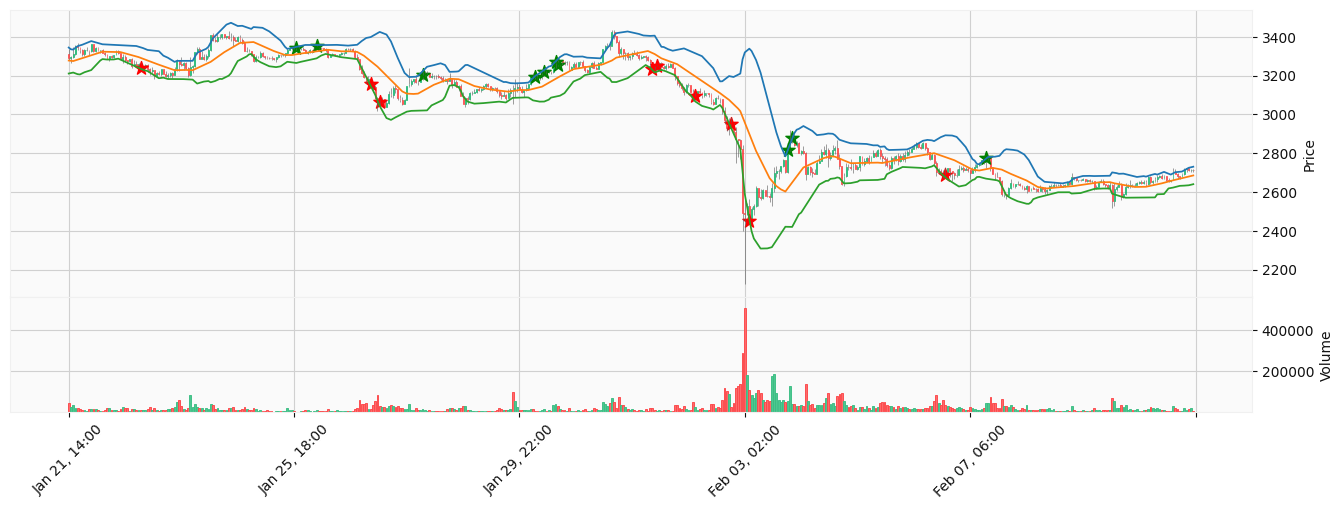

In [34]:
df['osci_bb_buy'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_support']) and row['rsi_trade'] == 'buy' else None, axis=1)
df['osci_bb_sell'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_resistance']) and row['rsi_trade'] == 'sell' else None, axis=1)
osci_bb_buy_count = df['osci_bb_buy'].count()
osci_bb_sell_count = df['osci_bb_sell'].count()

print(f"osci_bb_buy count: {osci_bb_buy_count}")
print(f"osci_bb_sell count: {osci_bb_sell_count}")

# Define the Bollinger Bands
bbands = mpf.make_addplot(df[['bb_upper', 'bb_middle', 'bb_lower']])

# Define the buy and sell signals
buy_signals = mpf.make_addplot(df['osci_bb_buy'], type='scatter', markersize=100, marker='*', color='red')
sell_signals = mpf.make_addplot(df['osci_bb_sell'], type='scatter', markersize=100, marker='*', color='green')

# Plot the candlestick chart with Bollinger Bands and buy/sell signals
mpf.plot(df, type='candle', addplot=[bbands, buy_signals, sell_signals], volume=True, style='yahoo', figratio=(3, 1))

Testing combination of BB and RSI and OSCI

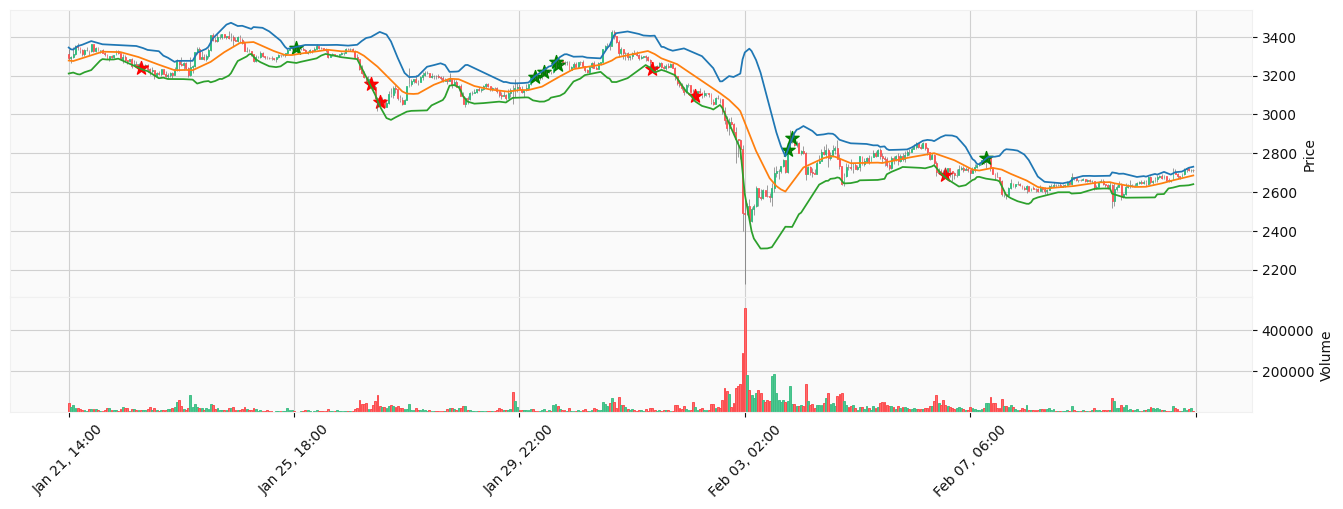

In [38]:
df['osci_bb_buy'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_support']) and row['stochastic_trade'] == 'buy' and row['rsi_trade'] == 'buy' else None, axis=1)
df['osci_bb_sell'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_resistance']) and row['stochastic_trade'] == 'sell' and row['rsi_trade'] == 'sell' else None, axis=1)

# Define the Bollinger Bands
bbands = mpf.make_addplot(df[['bb_upper', 'bb_middle', 'bb_lower']])

# Define the buy and sell signals
buy_signals = mpf.make_addplot(df['osci_bb_buy'], type='scatter', markersize=100, marker='*', color='red')
sell_signals = mpf.make_addplot(df['osci_bb_sell'], type='scatter', markersize=100, marker='*', color='green')

# Plot the candlestick chart with Bollinger Bands and buy/sell signals
mpf.plot(df, type='candle', addplot=[bbands, buy_signals, sell_signals], volume=True, style='yahoo', figratio=(3, 1))

Test with trend reversal detection by candlestick

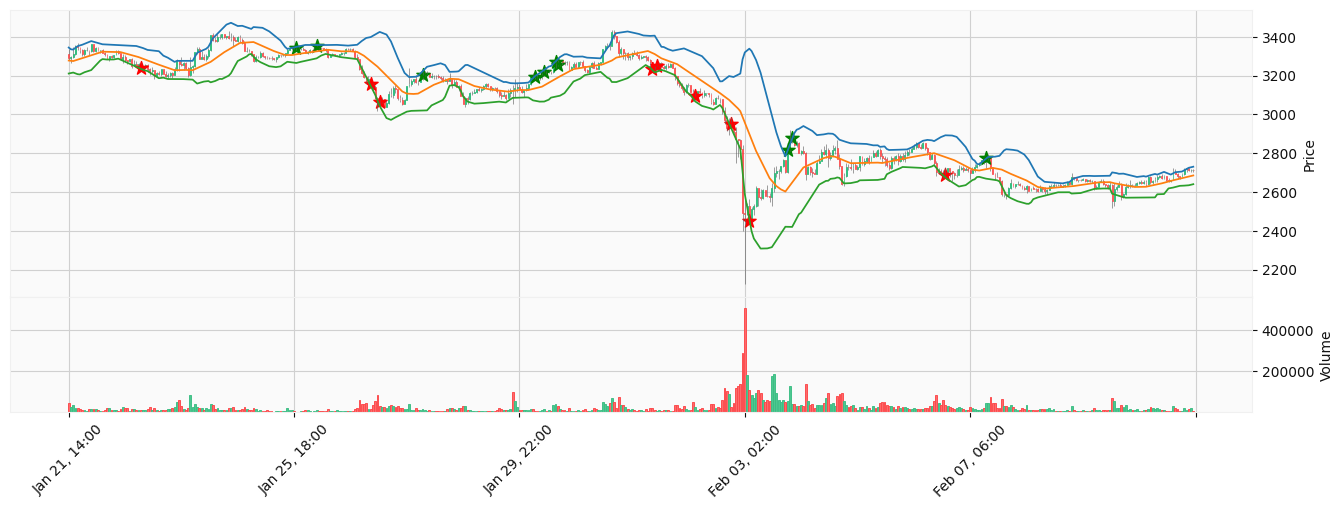

bullish reversal count: 496
bearish reversal count: 496
time
2025-01-21 14:00:00       None
2025-01-21 15:00:00       None
2025-01-21 16:00:00       None
2025-01-21 17:00:00          0
2025-01-21 18:00:00          0
                        ...   
2025-02-11 05:00:00          0
2025-02-11 06:00:00          0
2025-02-11 07:00:00          0
2025-02-11 08:00:00    2715.29
2025-02-11 09:00:00       None
Name: bullish_reversal, Length: 500, dtype: object


In [ ]:
import numpy as np

def support_resistance(df):
    df['ath'] = df['high'].rolling(window=len(df), min_periods=1).max().shift(1)
    df['atl'] = df['low'].rolling(window=len(df), min_periods=1).min().shift(1)
    return df

df = support_resistance(df)
df['ath'] = df.apply(lambda row: row['close'] if pd.notnull(row['ath']) and pd.notnull(row['near_bb_support']) and row['rsi_trade'] == 'buy' else None, axis=1)
df['atl'] = df.apply(lambda row: row['close'] if pd.notnull(row['atl']) and pd.notnull(row['near_bb_resistance']) and row['rsi_trade'] == 'sell' else None, axis=1)
buy_signals = mpf.make_addplot(df['ath'], type='scatter', markersize=100, marker='*', color='yellow')
sell_signals = mpf.make_addplot(df['atl'], type='scatter', markersize=100, marker='*', color='blue')
# ===================================================================================================
def bb_reversal(df, window=4):
    df['bullish_reversal'] = None
    df['bearish_reversal'] = None
    
    for i in range(window, len(df)):
        window_df = df.iloc[i-window:i]
        # Detect bullish reversal
        if (window_df['close'].iloc[-1] > window_df['open'].iloc[-1] and 
            window_df['close'].iloc[-1] > window_df['close'].iloc[-2] and 
            window_df['close'].iloc[-2] < window_df['close'].iloc[-3]):
            df.at[window_df.index[-1], 'bullish_reversal'] = window_df['close'].iloc[-1]
        else:
            df.at[window_df.index[-1], 'bullish_reversal'] = 0
        
        # Detect bearish reversal
        if (window_df['close'].iloc[-1] < window_df['open'].iloc[-1] and 
            window_df['close'].iloc[-1] < window_df['close'].iloc[-2] and 
            window_df['close'].iloc[-2] > window_df['close'].iloc[-3]):
            df.at[window_df.index[-1], 'bearish_reversal'] = window_df['close'].iloc[-1]
        else:
            df.at[window_df.index[-1], 'bearish_reversal'] = 0
    return df

df['osci_bb_buy'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_support']) and row['rsi_trade'] == 'buy' else None, axis=1)
df['osci_bb_sell'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_resistance']) and row['rsi_trade'] == 'sell' else None, axis=1)

# ========= if BB buy and RSI buy ==========
# Call bb_reversal function if 'osci_bb_buy' is not null
if df['osci_bb_buy'].notnull().any():
    df = bb_reversal(df)
    # Plot the candlestick chart with Bollinger Bands and buy/sell signals
    # Define the bullish and bearish reversal signals
    if df['bullish_reversal'].notnull().any() and df['bullish_reversal'].apply(lambda x: isinstance(x, (int, float)) and x > 1).any():
        bullish_reversal_signals = mpf.make_addplot(df['osci_bb_buy'].replace(0, np.nan), type='scatter', markersize=100, marker='*', color='red' )
if df['osci_bb_sell'].notnull().any() and df['bearish_reversal'].notnull().any() and df['bearish_reversal'].apply(lambda x: isinstance(x, (int, float)) and x > 1).any():
    bearish_reversal_signals = mpf.make_addplot(df['osci_bb_sell'].replace(0, np.nan), type='scatter', markersize=100, marker='*', color='green')

# Define the Bollinger Bands
bbands = mpf.make_addplot(df[['bb_upper', 'bb_middle', 'bb_lower']])

# Define the buy and sell signals
# buy_signals = mpf.make_addplot(df['osci_bb_buy'], type='scatter', markersize=100, marker='*', color='red')
# sell_signals = mpf.make_addplot(df['osci_bb_sell'], type='scatter', markersize=100, marker='*', color='green')

# Plot the candlestick chart with Bollinger Bands, buy/sell signals, and reversal signals
mpf.plot(df, type='candle', addplot=[bbands, bullish_reversal_signals, bearish_reversal_signals, buy_signals, sell_signals], volume=True, style='yahoo', figratio=(3, 1))

bullish_reversal_signals = df['bullish_reversal'].count()
bearish_reversal_signals = df['bearish_reversal'].count()

print(f"bullish reversal count: {bullish_reversal_signals}")
print(f"bearish reversal count: {bearish_reversal_signals}")
print(df['bullish_reversal'])

# ===================================================================================================
